In [1]:
import praw
import configparser
import pandas as pd
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration

In [2]:
# 1. CONFIGURATION

SEARCH_TERM = '("Apple Vision Pro" OR VisionPro)' 
SUBREDDITS = ['apple', 'virtualreality', 'technology'] # Subreddits to search
POST_LIMIT = 500 # Request up to 500 posts per subreddit initially

# Read configs
config = configparser.ConfigParser()
config.read('config.ini')

# 2. INITIALIZE PRAW CLIENT
try:
    # Initialize PRAW using the 'script' application method (user authentication)
    reddit = praw.Reddit(
        client_id=config['reddit']['client_id'],
        client_secret=config['reddit']['client_secret'],
        user_agent=config['reddit']['user_agent'],
        username=config['reddit']['username'],
        password=config['reddit']['password']
    )
    # Ensure the log in successful.
    print(f"PRAW client initialized. Logged in as: {reddit.user.me().name}")

except KeyError as e:
    print(f"FATAL ERROR: Missing Reddit credential in config.ini. Check key: {e}")
    exit()
except Exception as e:
    print(f"An error occurred during PRAW initialization or login: {e}")
    exit()

# 3. RETRIEVE AND COLLECT SUBMISSIONS
collected_posts = []

print(f"\n--- Starting data collection across {len(SUBREDDITS)} subreddits ---")

for subreddit_name in SUBREDDITS:
    print(f"Searching r/{subreddit_name}...")
    try:
        # Get the Subreddit instance
        subreddit = reddit.subreddit(subreddit_name)
        
        # Search the subreddit for the specified term, limiting the number of posts
        # .top(time_filter='month') is often a good filter for relevant discussions
        for submission in subreddit.search(SEARCH_TERM, limit=POST_LIMIT):
            # Only collect full text posts (self-posts) or external link posts with relevant titles/comments
            collected_posts.append({
                'id': submission.id,
                'subreddit': subreddit_name,
                'title': submission.title,
                'text': submission.selftext, # The body of a self-post
                'score': submission.score,
                'num_comments': submission.num_comments,
                'created_utc': submission.created_utc,
                'url': submission.url
            })
            
    except Exception as e:
        print(f"Skipping r/{subreddit_name} due to an error: {e}")
        continue # Move to the next subreddit

print(f"\n Data Collection Complete. Total submissions collected: {len(collected_posts)}")


# 4. CONVERT TO DATAFRAME AND DISPLAY SAMPLE
if collected_posts:
    df = pd.DataFrame(collected_posts)
    
    # Filter out empty text fields and convert timestamp
    df['created_at'] = pd.to_datetime(df['created_utc'], unit='s')
    
    print("\n--- Sample of Retrieved Data (First 5 Rows) ---")
    print(df[['subreddit', 'title', 'score', 'num_comments', 'created_at']].head())
    
    # The next step is to proceed with the sentiment analysis (text cleaning and VADER scoring)
else:
    print("\nNo posts were found matching the search criteria.")

PRAW client initialized. Logged in as: Afraid-Medicine4769

--- Starting data collection across 3 subreddits ---
Searching r/apple...
Searching r/virtualreality...
Searching r/technology...

 Data Collection Complete. Total submissions collected: 592

--- Sample of Retrieved Data (First 5 Rows) ---
  subreddit                                              title  score  \
0     apple     FCC Accidentally Leaks Apple's Next Vision Pro   2648   
1     apple  This is Apple Vision Pro, the mixed reality he...  17125   
2     apple   the thing no one will say about Apple Vision Pro   4294   
3     apple  Apple Vision Pro available in the U.S. on Febr...   3974   
4     apple  Report: Apple May Stop Producing Vision Pro by...   2211   

   num_comments          created_at  
0           290 2025-09-30 22:51:01  
1          9088 2023-06-05 18:23:55  
2          1324 2024-02-03 20:53:36  
3          1471 2024-01-08 13:58:58  
4           644 2024-10-23 13:18:35  


# Data cleaning

- Fill missing values
- Combine the title and text into a single column

In [3]:
# 1. Fill missing 'text' (post body) with an empty string
df['text'] = df['text'].fillna('')

# 2. Create a combined text column for analysis
# We concatenate the title and the post body
df['full_text'] = df['title'] + ' ' + df['text']

# Display the size of the DataFrame (should be 591)
print(f"DataFrame size after cleaning: {len(df)}")

DataFrame size after cleaning: 592


- Text normalisation = remove elements that will confuse the sentiment analyzer (like links, special characters, and converting everything to lowercase).

In [4]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs (starts with http or https)
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Remove special characters, keeping only letters and spaces
    # Note: We are being slightly aggressive here to ensure clean input for VADER
    text = re.sub(r'[^a-z\s]', '', text) 
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply the cleaning function to the combined text column
df['clean_text'] = df['full_text'].apply(clean_text)

# Show a sample of the cleaned data
print("\n--- Sample of Cleaned Text ---")
print(df['clean_text'].head())


--- Sample of Cleaned Text ---
0        fcc accidentally leaks apples next vision pro
1    this is apple vision pro the mixed reality hea...
2     the thing no one will say about apple vision pro
3     apple vision pro available in the us on february
4    report apple may stop producing vision pro by ...
Name: clean_text, dtype: object


In [5]:
# Initialize the VADER analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get VADER scores
def get_vader_scores(text):
    vs = analyzer.polarity_scores(text)
    return vs

# Apply the function to the cleaned text column
df['vader_scores'] = df['clean_text'].apply(get_vader_scores)

# Extract the compound score (the normalized, single sentiment metric)
# The compound score ranges from -1 (most negative) to +1 (most positive)
df['compound_score'] = df['vader_scores'].apply(lambda x: x['compound'])

# --- Classify Sentiment ---
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['compound_score'].apply(classify_sentiment)

print("\n--- Sample with Sentiment Scores ---")
print(df[['title', 'compound_score', 'sentiment']].head())


--- Sample with Sentiment Scores ---
                                               title  compound_score sentiment
0     FCC Accidentally Leaks Apple's Next Vision Pro         -0.1027  Negative
1  This is Apple Vision Pro, the mixed reality he...          0.2500  Positive
2   the thing no one will say about Apple Vision Pro         -0.0516  Negative
3  Apple Vision Pro available in the U.S. on Febr...          0.2500  Positive
4  Report: Apple May Stop Producing Vision Pro by...         -0.0516  Negative


# Overall Sentiment Breakdown

- Calculate Sentiment Totals

In [6]:
# Calculate the total counts for each sentiment category
sentiment_counts = df['sentiment'].value_counts()

# Calculate the percentage for a clearer presentation
sentiment_percentages = df['sentiment'].value_counts(normalize=True) * 100

print("\n--- Overall Sentiment Breakdown (Counts) ---")
print(sentiment_counts)
print("\n--- Overall Sentiment Breakdown (Percentages) ---")
print(sentiment_percentages.round(2))


--- Overall Sentiment Breakdown (Counts) ---
sentiment
Positive    510
Negative     70
Neutral      12
Name: count, dtype: int64

--- Overall Sentiment Breakdown (Percentages) ---
sentiment
Positive    86.15
Negative    11.82
Neutral      2.03
Name: proportion, dtype: float64


# Sentiment by Subreddit (Comparative Analysis)

In [7]:
# Group by subreddit and count the sentiment categories
sentiment_by_subreddit = df.groupby('subreddit')['sentiment'].value_counts().unstack(fill_value=0)

# Calculate percentages for comparison (optional, but helpful)
sentiment_by_subreddit_pct = sentiment_by_subreddit.apply(lambda x: 100 * x / x.sum(), axis=1).round(1)

print("\n--- Sentiment Counts by Subreddit ---")
print(sentiment_by_subreddit)
print("\n--- Sentiment Percentages by Subreddit ---")
print(sentiment_by_subreddit_pct)


--- Sentiment Counts by Subreddit ---
sentiment       Negative  Neutral  Positive
subreddit                                  
apple                 27        6       207
technology            19        2        95
virtualreality        24        4       208

--- Sentiment Percentages by Subreddit ---
sentiment       Negative  Neutral  Positive
subreddit                                  
apple               11.2      2.5      86.2
technology          16.4      1.7      81.9
virtualreality      10.2      1.7      88.1


/var/folders/jc/32xy7t714y5clrhjsh4zr3d40000gn/T/ipykernel_2971/4105872738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, order=['Positive', 'Neutral', 'Negative'], palette={'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'})


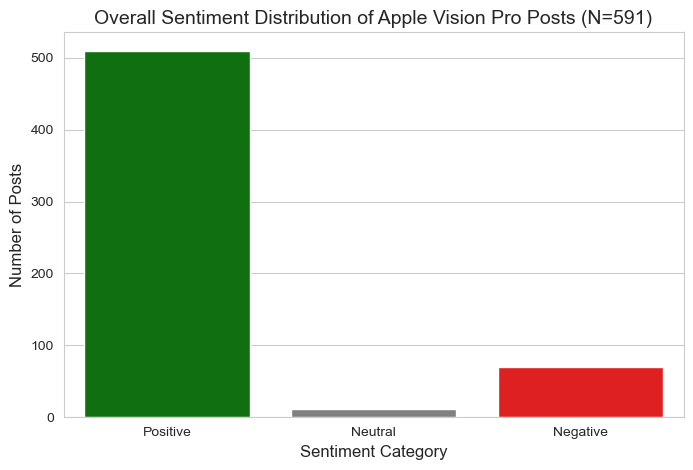

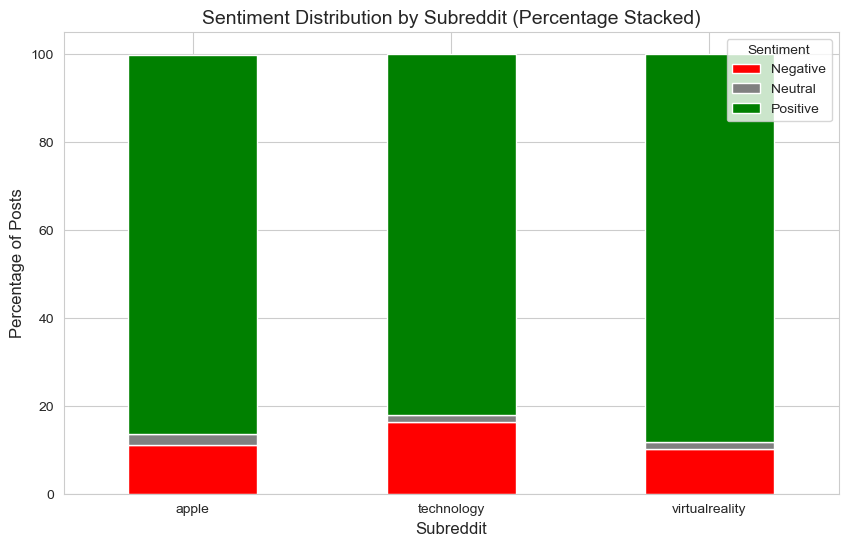

In [8]:
# Set a style for the plots
sns.set_style("whitegrid")

# --- Plot 1: Overall Sentiment Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, order=['Positive', 'Neutral', 'Negative'], palette={'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'})
plt.title('Overall Sentiment Distribution of Apple Vision Pro Posts (N=591)', fontsize=14)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.show()


# --- Plot 2: Sentiment Distribution by Subreddit (Comparison) ---
# Re-use the sentiment_by_subreddit_pct calculated in Action B
sentiment_by_subreddit_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color={'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'})
plt.title('Sentiment Distribution by Subreddit (Percentage Stacked)', fontsize=14)
plt.xlabel('Subreddit', fontsize=12)
plt.ylabel('Percentage of Posts', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()